In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Classroom', 'f2023010568 mid hareem tahir.gdoc', 'Cv about.pdf', 'Untitled document (7).gdoc', 'f2023105068 cyber lab.gdoc', 'Untitled document (6).gdoc', 'Untitled document (5).gdoc', 'DOC-20260515-WA0035..pdf', 'Mycv (1).pdf', 'Mycv.pdf', 'sna assign 1.gdoc', 'F2023105068 ossdasg2.gdoc', 'f2023105068 graded lab.gdoc', '21 century assignment 1', 'Untitled document (4).gdoc', 'f2023105068 hareem tahir assignment 1.gdoc', 'Untitled document (3).gdoc', 'Y2 presentation list.xlsx', '21 century asg 2', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', 'Sna y2 presentation list.gsheet', 'Hareem_Tahir_CV.pdf', 'Colab Notebooks', 'Untitled document.gdoc', '13-14--Machine Learning Lecture # 13 and 14.gdoc', 'BRISC_ML_Project']


In [ ]:
features_dir = "/content/drive/MyDrive/BRISC_ML_Project/features"

print(os.listdir(features_dir))

['X_test_pca.npy', 'y_test.npy', 'y_train.npy', 'X_train_pca.npy', 'pca_model.pkl', 'knn_model.pkl', 'label_map.json']


In [ ]:
import numpy as np

X_train_pca = np.load(
    "/content/drive/MyDrive/BRISC_ML_Project/features/X_train_pca.npy"
)

X_test_pca = np.load(
    "/content/drive/MyDrive/BRISC_ML_Project/features/X_test_pca.npy"
)

y_train = np.load(
    "/content/drive/MyDrive/BRISC_ML_Project/features/y_train.npy"
)

y_test = np.load(
    "/content/drive/MyDrive/BRISC_ML_Project/features/y_test.npy"
)

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
print("X_train shape:", X_train_pca.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test_pca.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5000, 1485)
y_train shape: (5000,)
X_test shape: (1000, 1485)
y_test shape: (1000,)


In [ ]:
import json

with open(
    "/content/drive/MyDrive/BRISC_ML_Project/features/label_map.json",
    "r"
) as f:
    label_map = json.load(f)

print(label_map)

{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [ ]:
classes = [
    class_name
    for class_name, label in sorted(
        label_map.items(),
        key=lambda x: int(x[1])
    )
]

print(classes)

['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(
    X_train_pca,
    y_train
)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [50, 100, 200]},
             scoring='f1_macro')

In [ ]:
print("Best Parameters:", grid_rf.best_params_)

print(
    "Best Cross-Validation Macro F1:",
    grid_rf.best_score_
)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best Cross-Validation Macro F1: 0.4556119794977886


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_pca)

print("Prediction completed!")

Prediction completed!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

print(f"Accuracy: {rf_accuracy * 100:.2f}%")
print(f"Macro Precision: {rf_precision * 100:.2f}%")
print(f"Macro Recall: {rf_recall * 100:.2f}%")
print(f"Macro F1: {rf_f1 * 100:.2f}%")

Accuracy: 88.70%
Macro Precision: 89.88%
Macro Recall: 89.74%
Macro F1: 89.65%


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      glioma       0.90      0.78      0.84       254
  meningioma       0.84      0.83      0.83       306
    no_tumor       0.97      0.99      0.98       140
   pituitary       0.89      0.98      0.93       300

    accuracy                           0.89      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.89      0.89      0.89      1000



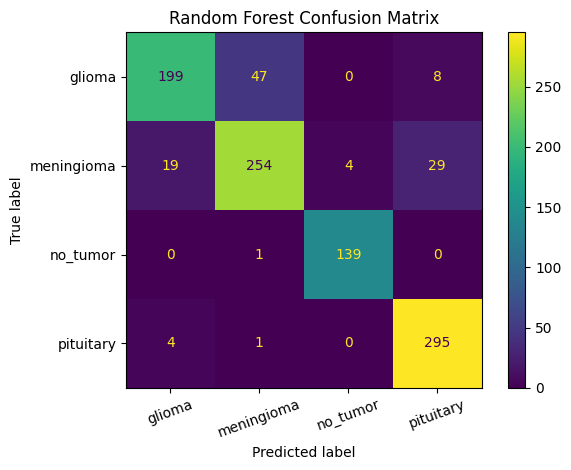

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=classes
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [ ]:
rf_results = {
    "Model": "Random Forest",
    "Best Parameters": grid_rf.best_params_,
    "Accuracy": rf_accuracy,
    "Macro Precision": rf_precision,
    "Macro Recall": rf_recall,
    "Macro F1": rf_f1
}

rf_results

{'Model': 'Random Forest',
 'Best Parameters': {'max_depth': None, 'n_estimators': 200},
 'Accuracy': 0.887,
 'Macro Precision': 0.8988156034186692,
 'Macro Recall': 0.8974301006491836,
 'Macro F1': 0.8965413161129359}

In [ ]:
import joblib
import os

model_path = "/content/drive/MyDrive/BRISC_ML_Project/features/random_forest_model.pkl"

joblib.dump(
    best_rf,
    model_path
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [ ]:
import pandas as pd

knn_results = {
    "Model": "KNN",
    "Accuracy": 0.8910,
    "Macro Precision": 0.8995,
    "Macro Recall": 0.9040,
    "Macro F1": 0.8986
}

comparison = pd.DataFrame([
    knn_results,
    {
        "Model": "Random Forest",
        "Accuracy": rf_results["Accuracy"],
        "Macro Precision": rf_results["Macro Precision"],
        "Macro Recall": rf_results["Macro Recall"],
        "Macro F1": rf_results["Macro F1"]
    }
])

comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,KNN,0.891,0.899500,0.90400,0.898600
1,Random Forest,0.887,0.898816,0.89743,0.896541


In [ ]:
comparison_percent = comparison.copy()

for col in [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]:
    comparison_percent[col] = (
        comparison_percent[col] * 100
    ).round(2)

comparison_percent

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,KNN,89.1,89.95,90.40,89.86
1,Random Forest,88.7,89.88,89.74,89.65


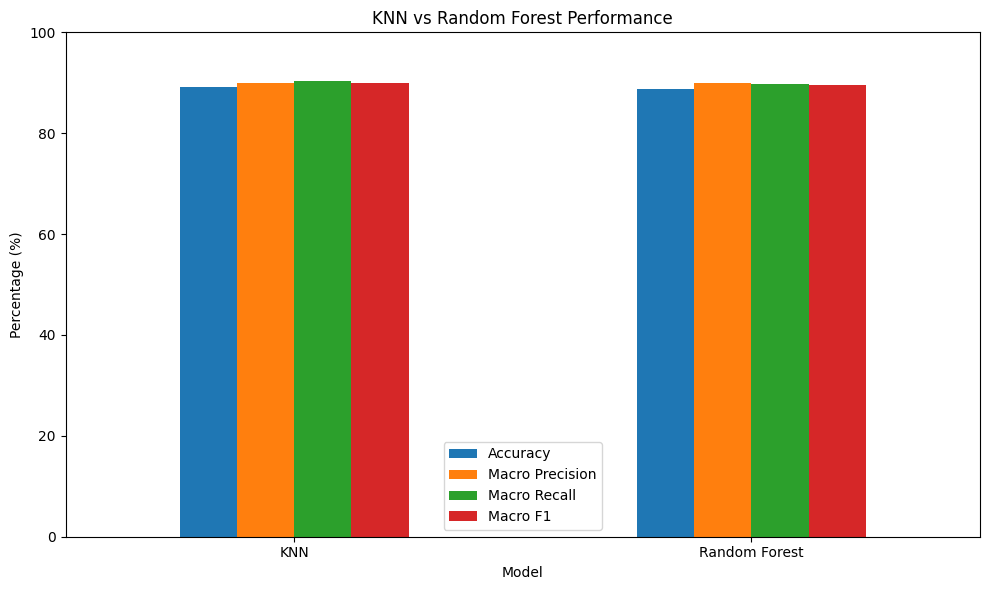

In [ ]:
comparison_percent.set_index("Model")[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("KNN vs Random Forest Performance")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

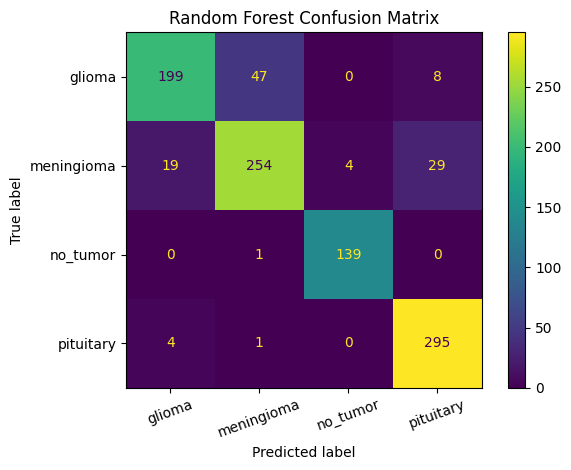

Random Forest confusion matrix saved successfully!


In [23]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

os.makedirs(
    "/content/drive/MyDrive/BRISC_ML_Project/results",
    exist_ok=True
)

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=classes
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/BRISC_ML_Project/results/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Random Forest confusion matrix saved successfully!")